In [1]:
using UnPack
using Plots

In [2]:
# function to model density dependent reproduction (Dye exponential form)
# X is total population size, C is maximum population size
function F(X, h, k, C)
    if X < C
        if  X > 0.
            return exp(-h*X^k)  # exponential decrease in reproduction rate
        else
            return 1.
        end
    else
        return 0. # if maximum population size is reached, reproduction rate is zero
    end
end

F (generic function with 1 method)

In [3]:
function rep_rate(x, p)

    @unpack b, phi, h, k, C, mate_mod = p
    m_f, m_m, w_f, w_m = x

    # get the probability of mating with wildtype
    if mate_mod == "female"    # use the female popuation to approximate the male population
        mate_prob = if m_f + w_f == 0
            0
        else
            m_f/(m_f + w_f)
        end
    elseif mate_mod == "male"   # use the male population directly
        mate_prob = if m_m + w_m == 0
            0
        else
            m_m/(m_m + w_m)
        end
    end

    # get the reproduction rate, simplified formula with u = v = 1 fixed
    X = m_f + w_f

    return b*mate_prob*m_f*F(X,h,k,C)      

end


rep_rate (generic function with 1 method)

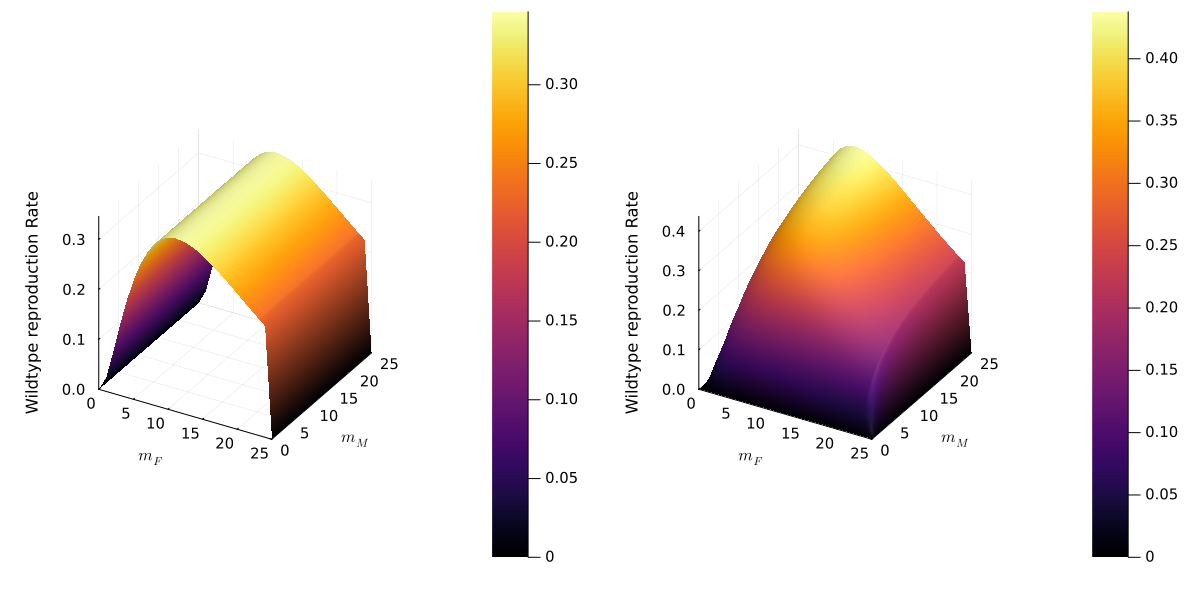

In [16]:
using Setfield
using Plots

m_f = m_m = range(0, 25, length = 26)
w_f = w_m = 5
f(m_f, m_m) = rep_rate([m_f, m_m, w_f, w_m], params)

params = (b = 0.54, phi = 0.85, h = 0.3, k = 0.76, C = 30., mate_mod = "female")
p_fem_mate = plot(m_f, m_m, f, st = [:surface], xlabel = "\$m_F\$", ylabel = "\$m_M\$", zlabel = "Wildtype reproduction Rate")

params = @set params.mate_mod = "male"
p_male_mate = plot(m_f, m_m, f, st = [:surface], xlabel = "\$m_F\$", ylabel = "\$m_M\$", zlabel = "Wildtype reproduction Rate")

p = plot(p_fem_mate, p_male_mate, layout = (1, 2), size = (1200, 600), xtickfont=font(10), ytickfont=font(10), ztickfont=font(10))
savefig(p, "reproduction_rate_surface.pdf")
p